In [65]:
import pandas as pd
import matplotlib.pyplot as plt
d = pd.read_csv("./data/ili_data.csv")
d_hhs3 = d.loc[ d.region == "hhs3" ].reset_index()

#Ignore the next 4 lines
d_hhs3["week"] = [  int(str(row.epiweek)[-2:])   for idx,row in d_nat.iterrows() ] 
d_hhs3["year"] = [  int(str(row.epiweek)[:-2])   for idx,row in d_nat.iterrows() ] 
x_ticks       = d_hhs3.loc[d_hhs3.week==40].index
x_tick_labels = d_hhs3.loc[d_hhs3.week==40, "year"]

               Vaccine     Geography  FIPS     Year  Month   Dimension  \
58  Seasonal Influenza  Pennsylvania    42  2015-16      2  >=6 Months   
59  Seasonal Influenza  Pennsylvania    42  2015-16      3  >=6 Months   
60  Seasonal Influenza  Pennsylvania    42  2015-16      4  >=6 Months   
61  Seasonal Influenza  Pennsylvania    42  2015-16      5  >=6 Months   
62  Seasonal Influenza  Pennsylvania    42  2015-16      7  >=6 Months   

    Estimate(%)  New_per_Month  YearNumeric  year  month       Date  
58         46.9            1.4         2015  2015      2 2015-02-01  
59         47.5            0.6         2015  2015      3 2015-03-01  
60         48.0            0.5         2015  2015      4 2015-04-01  
61         48.2            0.2         2015  2015      5 2015-05-01  
62          0.4            0.4         2015  2015      7 2015-07-01  
   index release_date region   issue  epiweek  lag  num_ili  num_patients  \
0      3   2017-10-24   hhs3  201740   201501  143     775

[Text(39, 0, '2015'),
 Text(91, 0, '2016'),
 Text(143, 0, '2017'),
 Text(195, 0, '2018'),
 Text(247, 0, '2019'),
 Text(299, 0, '2020'),
 Text(352, 0, '2021'),
 Text(404, 0, '2022'),
 Text(456, 0, '2023'),
 Text(508, 0, '2024'),
 Text(560, 0, '2025')]

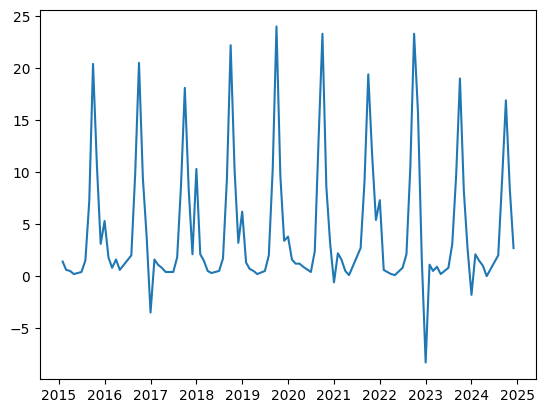

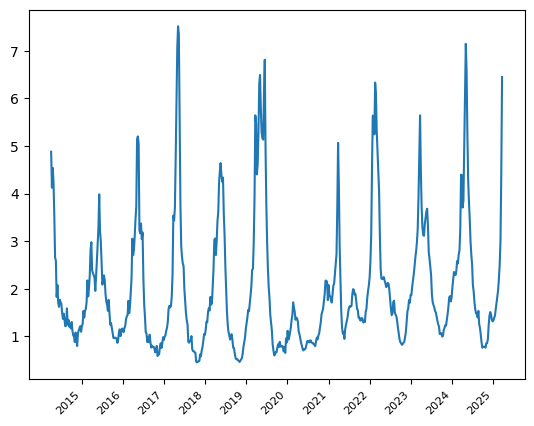

In [80]:

vax = pd.read_csv("./data/Influenza_Vaccination_Coverage_PA.csv")
vax_2015_2025 = vax.loc[58: ] #selects only surveys after 2017
vax_2015_2025.rename(columns={'Season/Survey Year': 'Year'}, inplace=True) 
vax_2015_2025['YearNumeric'] = vax_2015_2025['Year'].str.split('-').str[0].astype(int)
vax_2015_2025['year'] = vax_2015_2025['YearNumeric']
vax_2015_2025['month'] = vax_2015_2025['Month']

vax_2015_2025['Date'] = pd.to_datetime(vax_2015_2025[['year', 'month']].assign(day=1))
print(vax_2015_2025.head())
print(d_hhs3.head())
fig, ax = plt.subplots() 
plt.plot (vax_2015_2025["Date"],vax_2015_2025["New_per_Month"])

fig, ax = plt.subplots() 
ax.plot(d_hhs3["wili"])
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_tick_labels, rotation =45, ha ="right", fontsize=8)

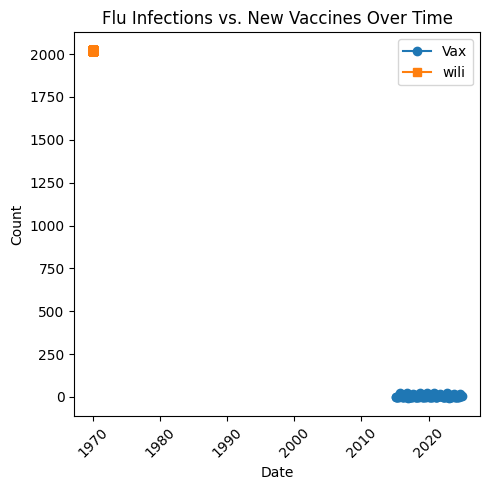

In [79]:
plt.figure(figsize=(5,5))

# Plot Vax
plt.plot(vax_2015_2025['Date'], vax_2015_2025["New_per_Month"], label='Vax', marker='o')

# Plot wili
plt.plot(d_hhs3["wili"],d_hhs3["year"], label='wili', marker='s')
 
plt.xlabel('Date')
plt.ylabel('Count')
plt.title('Flu Infections vs. New Vaccines Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()